# Macroeconomic Similarity Engine

**Project:** Financial Planning & Analysis Intelligence Platform

**Notebook:** `08-macroeconomic-similarity-engine.ipynb`

In [2]:
# ==========================================
# Notebook 08
# Macroeconomic Similarity Engine
# ==========================================

import pandas as pd
import numpy as np

from sentence_transformers import SentenceTransformer

from sklearn.metrics.pairwise import cosine_similarity

d:\Books\projects-nlp-transformers-learning\.projectnlps\Lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


In [3]:
financial_df = pd.read_csv("../data/financial_embedding_corpus.csv")

financial_df.head()

,ticker,quarter,revenue_million,gross_margin_pct,operating_income_million,net_income_million,eps,earnings_call,risk_factors,mda_section,...,sentences,chunks,sentiment,confidence,weighted_sentiment,guidance_score,positive_guidance_score,total_risk_score,normalized_risk_score,financial_document
0,ABC,2023-Q1,120,58,22,16,1.20,\n Demand remained strong across enterp...,\n Inflation remains a concern.\n ...,\n Management believes demand trends re...,...,['Demand remained strong across enterprise cus...,['Demand remained strong across enterprise cus...,positive,0.956167,0.956167,1,1,2,1.0,\n Demand remained strong across enterp...
1,ABC,2023-Q2,128,60,25,18,1.35,\n Enterprise adoption accelerated.\n ...,\n Competitive pressure exists.\n ...,\n New product launches contributed pos...,...,"['Enterprise adoption accelerated.', 'Pricing ...",['Enterprise adoption accelerated. Pricing pre...,positive,0.957692,0.957692,1,2,1,0.5,\n Enterprise adoption accelerated.\n ...
2,ABC,2023-Q3,138,61,28,21,1.52,\n Customer demand exceeded expectation...,\n Geopolitical uncertainty remains.\n ...,\n Strong customer growth across region...,...,"['Customer demand exceeded expectations.', 'Su...",['Customer demand exceeded expectations. Suppl...,positive,0.951876,0.951876,2,0,1,0.5,\n Customer demand exceeded expectation...
3,ABC,2023-Q4,150,63,32,24,1.72,\n Record quarter performance.\n ...,\n Macroeconomic slowdown remains possi...,\n Revenue growth exceeded internal exp...,...,"['Record quarter performance.', 'Management ex...",['Record quarter performance. Management expec...,positive,0.956653,0.956653,1,1,0,0.0,\n Record quarter performance.\n ...
4,ABC,2024-Q1,158,62,34,26,1.85,\n Strong start to the fiscal year driv...,\n Increased cyber security threats req...,\n Gross margin slightly contracted due...,...,['Strong start to the fiscal year driven by en...,['Strong start to the fiscal year driven by en...,positive,0.922371,0.922371,1,0,0,0.0,\n Strong start to the fiscal year driv...


In [4]:
macro_events = [
    {
        "event_name": "COVID Supply Chain Crisis",
        "description": """
        Global supply chain disruption.
        Shipping delays increased.
        Inventory shortages impacted businesses.
        Logistics bottlenecks reduced production.
        """,
    },
    {
        "event_name": "High Inflation Environment",
        "description": """
        Rising inflation increased operating costs.
        Pricing pressure affected profitability.
        Consumer demand weakened.
        """,
    },
    {
        "event_name": "Interest Rate Shock",
        "description": """
        Rapid interest rate increases.
        Financing costs rose.
        Corporate investment slowed.
        """,
    },
    {
        "event_name": "Currency Volatility Event",
        "description": """
        Foreign exchange fluctuations.
        Currency risk increased.
        International revenues became unstable.
        """,
    },
    {
        "event_name": "Regulatory Pressure Cycle",
        "description": """
        New regulations introduced.
        Compliance costs increased.
        Operational restrictions expanded.
        """,
    },
]

In [5]:
macro_df = pd.DataFrame(macro_events)

macro_df

,event_name,description
0,COVID Supply Chain Crisis,\n Global supply chain disruption.\n ...
1,High Inflation Environment,\n Rising inflation increased operating...
2,Interest Rate Shock,\n Rapid interest rate increases.\n ...
3,Currency Volatility Event,\n Foreign exchange fluctuations.\n ...
4,Regulatory Pressure Cycle,\n New regulations introduced.\n ...


In [6]:
embedding_model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")

In [7]:
macro_embeddings = embedding_model.encode(
    macro_df["description"].tolist(), show_progress_bar=True
)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [8]:
macro_embeddings.shape

(5, 768)

In [16]:
macro_embeddings

array([[ 0.00757791, -0.01920741, -0.03839689, ..., -0.03927467,
        -0.04926075, -0.04058783],
       [-0.02932695, -0.03860408, -0.01516334, ..., -0.0234901 ,
        -0.03403777,  0.01500642],
       [-0.04213525, -0.00119225, -0.00707374, ..., -0.03607406,
        -0.04324311,  0.01853346],
       [-0.01421523,  0.01367307, -0.01062536, ..., -0.02447569,
        -0.00127913,  0.0076646 ],
       [ 0.02317651,  0.01905702, -0.00808606, ...,  0.01208128,
        -0.06617427,  0.01903973]], dtype=float32)

In [9]:
risk_embeddings = embedding_model.encode(
    financial_df["risk_factors"].fillna("").tolist(), show_progress_bar=True
)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [10]:
risk_embeddings.shape

(12, 768)

In [11]:
similarity_matrix = cosine_similarity(risk_embeddings, macro_embeddings)

In [17]:
similarity_matrix.shape

(12, 5)

In [12]:
similarity_matrix

array([[0.55417913, 0.5839044 , 0.4041425 , 0.50862885, 0.36912203],
       [0.3904439 , 0.53223306, 0.35400707, 0.62403524, 0.38013703],
       [0.5008367 , 0.348696  , 0.32376426, 0.45626527, 0.5652323 ],
       [0.3483721 , 0.42263314, 0.49971616, 0.39154878, 0.3651234 ],
       [0.38106418, 0.3140326 , 0.3637733 , 0.25924456, 0.3684442 ],
       [0.4351036 , 0.54165673, 0.39961404, 0.5240953 , 0.3769349 ],
       [0.16542494, 0.2163477 , 0.1704103 , 0.2340745 , 0.31296617],
       [0.42179334, 0.39405164, 0.40583938, 0.39326257, 0.3824499 ],
       [0.5845183 , 0.4572553 , 0.42435262, 0.5173284 , 0.44238174],
       [0.39207742, 0.42471433, 0.51410824, 0.3763284 , 0.38317186],
       [0.39144394, 0.44391602, 0.36639935, 0.52356476, 0.26156715],
       [0.36775246, 0.44562083, 0.4006817 , 0.38139766, 0.4286626 ]],
      dtype=float32)

In [13]:
pd.DataFrame(similarity_matrix).head()

,0,1,2,3,4
0,0.554179,0.583904,0.404142,0.508629,0.369122
1,0.390444,0.532233,0.354007,0.624035,0.380137
2,0.500837,0.348696,0.323764,0.456265,0.565232
3,0.348372,0.422633,0.499716,0.391549,0.365123
4,0.381064,0.314033,0.363773,0.259245,0.368444


In [14]:
macro_matches = []

for i in range(len(financial_df)):

    scores = similarity_matrix[i]

    best_idx = np.argmax(scores)

    macro_matches.append(
        {
            "quarter": financial_df.iloc[i]["quarter"],
            "best_macro_event": macro_df.iloc[best_idx]["event_name"],
            "similarity_score": scores[best_idx],
        }
    )

In [15]:
macro_match_df = pd.DataFrame(macro_matches)

macro_match_df

,quarter,best_macro_event,similarity_score
0,2023-Q1,High Inflation Environment,0.583904
1,2023-Q2,Currency Volatility Event,0.624035
2,2023-Q3,Regulatory Pressure Cycle,0.565232
3,2023-Q4,Interest Rate Shock,0.499716
4,2024-Q1,COVID Supply Chain Crisis,0.381064
5,2024-Q2,High Inflation Environment,0.541657
6,2024-Q3,Regulatory Pressure Cycle,0.312966
7,2024-Q4,COVID Supply Chain Crisis,0.421793
8,2025-Q1,COVID Supply Chain Crisis,0.584518
9,2025-Q2,Interest Rate Shock,0.514108


In [18]:
for i in range(len(financial_df)):

    print("=" * 80)

    print(financial_df.iloc[i]["quarter"])

    print("=" * 80)

    scores = similarity_matrix[i]

    for idx, score in enumerate(scores):

        print(macro_df.iloc[idx]["event_name"], "->", round(score, 4))

2023-Q1
COVID Supply Chain Crisis -> 0.5542
High Inflation Environment -> 0.5839
Interest Rate Shock -> 0.4041
Currency Volatility Event -> 0.5086
Regulatory Pressure Cycle -> 0.3691
2023-Q2
COVID Supply Chain Crisis -> 0.3904
High Inflation Environment -> 0.5322
Interest Rate Shock -> 0.354
Currency Volatility Event -> 0.624
Regulatory Pressure Cycle -> 0.3801
2023-Q3
COVID Supply Chain Crisis -> 0.5008
High Inflation Environment -> 0.3487
Interest Rate Shock -> 0.3238
Currency Volatility Event -> 0.4563
Regulatory Pressure Cycle -> 0.5652
2023-Q4
COVID Supply Chain Crisis -> 0.3484
High Inflation Environment -> 0.4226
Interest Rate Shock -> 0.4997
Currency Volatility Event -> 0.3915
Regulatory Pressure Cycle -> 0.3651
2024-Q1
COVID Supply Chain Crisis -> 0.3811
High Inflation Environment -> 0.314
Interest Rate Shock -> 0.3638
Currency Volatility Event -> 0.2592
Regulatory Pressure Cycle -> 0.3684
2024-Q2
COVID Supply Chain Crisis -> 0.4351
High Inflation Environment -> 0.5417
Interes

In [19]:
macro_match_df["best_macro_event"].value_counts()

best_macro_event
High Inflation Environment    3
COVID Supply Chain Crisis     3
Currency Volatility Event     2
Regulatory Pressure Cycle     2
Interest Rate Shock           2
Name: count, dtype: int64

In [20]:
def find_historical_analog(query):

    query_embedding = embedding_model.encode(query)

    scores = cosine_similarity(query_embedding.reshape(1, -1), macro_embeddings)[0]

    ranked_idx = np.argsort(scores)[::-1]

    results = []

    for idx in ranked_idx:

        results.append(
            {
                "macro_event": macro_df.iloc[idx]["event_name"],
                "similarity": float(scores[idx]),
            }
        )

    return pd.DataFrame(results)

In [21]:
find_historical_analog("severe logistics delays and inventory shortages")

,macro_event,similarity
0,COVID Supply Chain Crisis,0.732342
1,Regulatory Pressure Cycle,0.344273
2,High Inflation Environment,0.341567
3,Currency Volatility Event,0.305275
4,Interest Rate Shock,0.301645


In [22]:
find_historical_analog("rising inflation and higher costs")

,macro_event,similarity
0,High Inflation Environment,0.710940
1,Currency Volatility Event,0.525107
2,Interest Rate Shock,0.522159
3,Regulatory Pressure Cycle,0.447993
4,COVID Supply Chain Crisis,0.395212


In [23]:
find_historical_analog("new government regulations increased compliance requirements")

,macro_event,similarity
0,Regulatory Pressure Cycle,0.772108
1,High Inflation Environment,0.293570
2,Interest Rate Shock,0.278427
3,Currency Volatility Event,0.209251
4,COVID Supply Chain Crisis,0.186092


In [24]:
macro_match_df["macro_risk_score"] = macro_match_df["similarity_score"]

In [25]:
macro_match_df

,quarter,best_macro_event,similarity_score,macro_risk_score
0,2023-Q1,High Inflation Environment,0.583904,0.583904
1,2023-Q2,Currency Volatility Event,0.624035,0.624035
2,2023-Q3,Regulatory Pressure Cycle,0.565232,0.565232
3,2023-Q4,Interest Rate Shock,0.499716,0.499716
4,2024-Q1,COVID Supply Chain Crisis,0.381064,0.381064
5,2024-Q2,High Inflation Environment,0.541657,0.541657
6,2024-Q3,Regulatory Pressure Cycle,0.312966,0.312966
7,2024-Q4,COVID Supply Chain Crisis,0.421793,0.421793
8,2025-Q1,COVID Supply Chain Crisis,0.584518,0.584518
9,2025-Q2,Interest Rate Shock,0.514108,0.514108


In [26]:
financial_macro_df = pd.merge(financial_df, macro_match_df, on="quarter")

In [27]:
financial_macro_df.head()

,ticker,quarter,revenue_million,gross_margin_pct,operating_income_million,net_income_million,eps,earnings_call,risk_factors,mda_section,...,confidence,weighted_sentiment,guidance_score,positive_guidance_score,total_risk_score,normalized_risk_score,financial_document,best_macro_event,similarity_score,macro_risk_score
0,ABC,2023-Q1,120,58,22,16,1.20,\n Demand remained strong across enterp...,\n Inflation remains a concern.\n ...,\n Management believes demand trends re...,...,0.956167,0.956167,1,1,2,1.0,\n Demand remained strong across enterp...,High Inflation Environment,0.583904,0.583904
1,ABC,2023-Q2,128,60,25,18,1.35,\n Enterprise adoption accelerated.\n ...,\n Competitive pressure exists.\n ...,\n New product launches contributed pos...,...,0.957692,0.957692,1,2,1,0.5,\n Enterprise adoption accelerated.\n ...,Currency Volatility Event,0.624035,0.624035
2,ABC,2023-Q3,138,61,28,21,1.52,\n Customer demand exceeded expectation...,\n Geopolitical uncertainty remains.\n ...,\n Strong customer growth across region...,...,0.951876,0.951876,2,0,1,0.5,\n Customer demand exceeded expectation...,Regulatory Pressure Cycle,0.565232,0.565232
3,ABC,2023-Q4,150,63,32,24,1.72,\n Record quarter performance.\n ...,\n Macroeconomic slowdown remains possi...,\n Revenue growth exceeded internal exp...,...,0.956653,0.956653,1,1,0,0.0,\n Record quarter performance.\n ...,Interest Rate Shock,0.499716,0.499716
4,ABC,2024-Q1,158,62,34,26,1.85,\n Strong start to the fiscal year driv...,\n Increased cyber security threats req...,\n Gross margin slightly contracted due...,...,0.922371,0.922371,1,0,0,0.0,\n Strong start to the fiscal year driv...,COVID Supply Chain Crisis,0.381064,0.381064


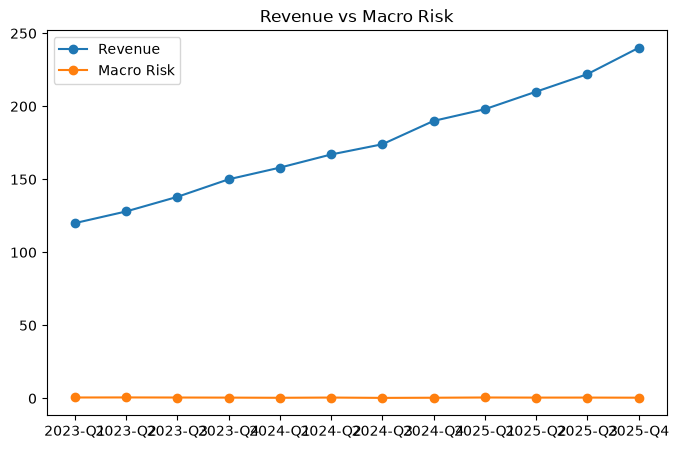

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    financial_macro_df["quarter"],
    financial_macro_df["revenue_million"],
    marker="o",
    label="Revenue",
)

plt.plot(
    financial_macro_df["quarter"],
    financial_macro_df["macro_risk_score"],
    marker="o",
    label="Macro Risk",
)

plt.legend()

plt.title("Revenue vs Macro Risk")

plt.show()

In [29]:
macro_match_df.to_csv("../data/macroeconomic_similarity_results.csv", index=False)

In [30]:
financial_macro_df.to_csv("../data/financial_macro_dataset.csv", index=False)

In [31]:
saved_df = pd.read_csv("../data/macroeconomic_similarity_results.csv")

saved_df.head()

,quarter,best_macro_event,similarity_score,macro_risk_score
0,2023-Q1,High Inflation Environment,0.583904,0.583904
1,2023-Q2,Currency Volatility Event,0.624035,0.624035
2,2023-Q3,Regulatory Pressure Cycle,0.565232,0.565232
3,2023-Q4,Interest Rate Shock,0.499716,0.499716
4,2024-Q1,COVID Supply Chain Crisis,0.381064,0.381064
